# Fase 2: Creación, Entrenamiento y Evaluación del Modelo CNN

## 1. Carga de los Datos Preprocesados
Comenzamos cargando los tensores unificados que generamos en la Fase 1. Gracias a nuestro procesamiento previo con OpenCV, estos datos ya integran las imágenes de nuestros datasets, estandarizadas a 64x64 píxeles en escala de grises.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.load('../dataset/datos_procesados/X_train.npy')
X_val   = np.load('../dataset/datos_procesados/X_val.npy')
X_test  = np.load('../dataset/datos_procesados/X_test.npy')
Y_train = np.load('../dataset/datos_procesados/Y_train.npy')
Y_val   = np.load('../dataset/datos_procesados/Y_val.npy')
Y_test  = np.load('../dataset/datos_procesados/Y_test.npy')

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de validación: {X_val.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (12618, 64, 64, 1)
Dimensiones de validación: (2704, 64, 64, 1)
Dimensiones de prueba: (2704, 64, 64, 1)


## 2. Definición de la Arquitectura del Modelo (CNN)

Para este problema de clasificación de imágenes, utilizaremos una **Red Neuronal Convolucional (CNN)**. 

### Justificación de las Capas:
* **Conv2D (Capas Convolucionales):** Son el núcleo del modelo. Detectan características espaciales como bordes y formas de los dedos.
* **MaxPooling2D:** Reduce la dimensionalidad de la imagen, conservando las características más importantes detectadas por la convolución y evitando el sobreajuste.
* **Flatten:** Aplana la matriz bidimensional resultante en un vector unidimensional.
* **Dense (Capa Oculta - ReLU):** Capa con función de activación ReLU que introduce no-linealidad y evita el problema del desvanecimiento del gradiente.
* **Dropout & L2 (Regularización):** Apagamos aleatoriamente un 50% de las neuronas en cada iteración y penalizamos los pesos grandes (L2) para evitar el *Overfitting*.
* **Dense (Capa de Salida - Softmax):** Tiene 10 neuronas (una para cada dígito) que generan una distribución de probabilidad.

### Búsqueda de Hiperparámetros y Complejidad
Antes de llegar a la arquitectura final presentada a continuación, se realizaron pruebas con modelos de diferente complejidad (por ejemplo, con solo 2 bloques convolucionales y sin regularización L2). Esto resultó en un claro sobreajuste. Posteriormente se probó modificar el Dropout a 0.2, pero la red actual (con 3 bloques, L2=0.001 y Dropout=0.5) fue la que entregó el mejor balance de pérdida en validación sin sobreajuste, demostrando ser la estructura más adecuada.

In [9]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Aplanamiento y Clasificación
model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001))) # Regularización L2
model.add(Dropout(0.5)) # Regularización Dropout (Apaga el 50% de neuronas)
model.add(Dense(10, activation='softmax')) # Salida de 10 clases

model.summary()

/home/dici/workspace/Taller-3-Sign-Language-Digits/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Configuración y Callbacks (Early Stopping y TensorBoard)
Utilizaremos el optimizador Adam por su adaptabilidad y rápida convergencia en modelos profundos, y la pérdida *Categorical Crossentropy* debido a que es un problema de clasificación multiclase con etiquetas en formato one-hot. Además, implementaremos **Early Stopping** (Punto 6 del taller) para detener el entrenamiento si el modelo deja de mejorar, y **TensorBoard** para monitoreo.

In [10]:
import os
import datetime
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

optimizador_estable = Adam(learning_rate=0.0005)

model.compile(optimizer=optimizador_estable, loss='categorical_crossentropy', metrics=['accuracy'])

# Configurar TensorBoard (guardará los logs en la carpeta principal)
log_dir = os.path.join("../logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

## 4. Entrenamiento del Modelo con Pesos Balanceados (Class Weights)
Dado que fusionamos múltiples datasets, calculamos dinámicamente los pesos de cada clase para obligar a la red a "prestarle más atención" a los dígitos que tienen menos fotografías, evitando sesgos.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Calcular los pesos de cada clase a partir de las etiquetas de entrenamiento
y_train_labels = np.argmax(Y_train, axis=1)  # convertir de one-hot a etiquetas enteras

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(pesos))

print("Pesos calculados por clase:", class_weights_dict)

# 2. Generador de imágenes (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05
)

batch_size = 32
epochs = 150

print("Iniciando entrenamiento estabilizado...")

history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    validation_data=(X_val, Y_val),
    epochs=epochs,
    class_weight=class_weights_dict,   # <- aquí se aplican los pesos
    callbacks=[early_stop, tensorboard_callback],
    verbose=1
)

Pesos calculados por clase: {0: np.float64(0.9904238618524333), 1: np.float64(1.00302066772655), 2: np.float64(0.9982594936708861), 3: np.float64(0.97211093990755), 4: np.float64(1.020873786407767), 5: np.float64(0.9865519937451134), 6: np.float64(0.995895816890292), 7: np.float64(1.002223987291501), 8: np.float64(1.00622009569378), 9: np.float64(1.0266883645240032)}
Iniciando entrenamiento estabilizado...
Epoch 1/150
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6406 - loss: 1.1509 - val_accuracy: 0.8820 - val_loss: 0.5198
Epoch 2/150
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8307 - loss: 0.6019 - val_accuracy: 0.9316 - val_loss: 0.3521
Epoch 3/150
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8779 - loss: 0.4761 - val_accuracy: 0.9493 - val_loss: 0.2704
Epoch 4/150
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9016 - loss: 0.4156 - val_accuracy: 0.9567 - val_loss: 0.2428
Epoch 5/150
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.91

## 5. Evaluación y Análisis de Resultados
Graficamos las curvas de aprendizaje y evaluamos con los datos de prueba (Test Data) que el modelo jamás ha visto.

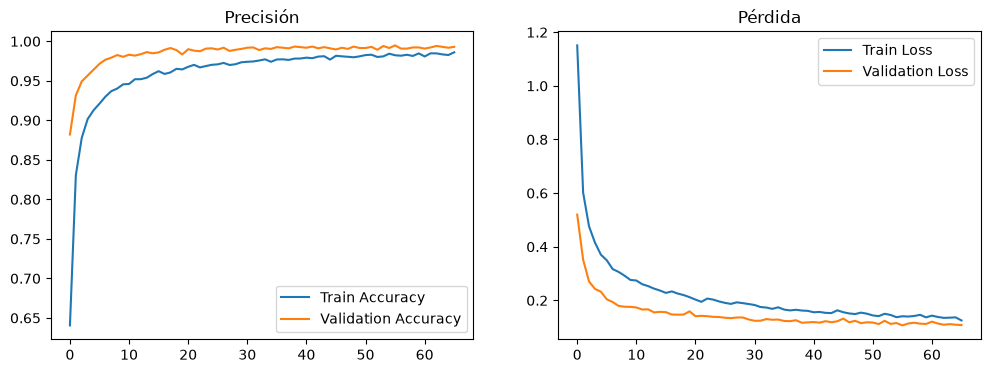

Precisión final en datos de PRUEBA: 99.37%


In [12]:
# Gráfica de Precisión y Pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Precisión')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Pérdida')
plt.show()

# Evaluación final en TEST
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Precisión final en datos de PRUEBA: {test_accuracy*100:.2f}%")

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


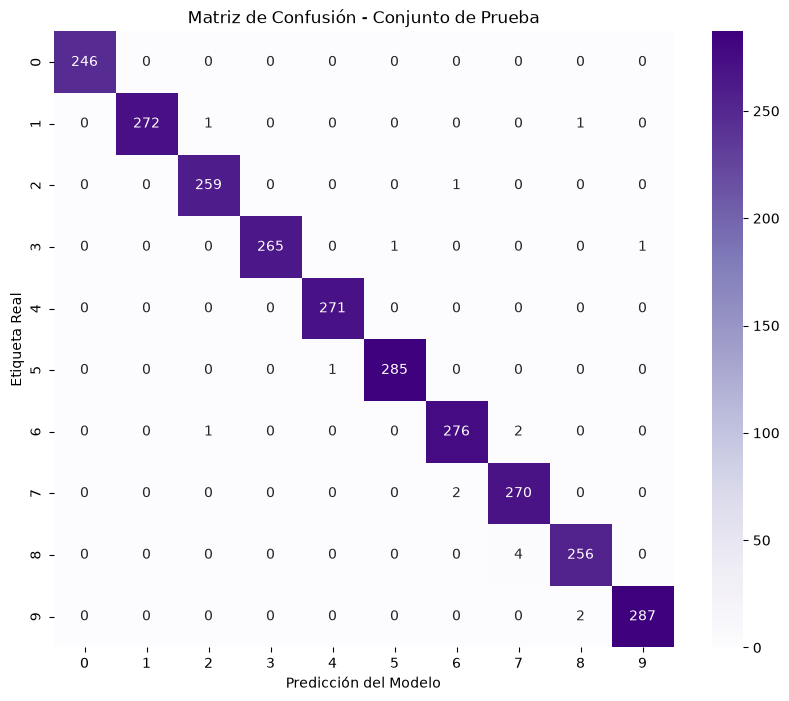

--- Reporte de Clasificación por Dígito ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       246
           1     1.0000    0.9927    0.9963       274
           2     0.9923    0.9962    0.9942       260
           3     1.0000    0.9925    0.9962       267
           4     0.9963    1.0000    0.9982       271
           5     0.9965    0.9965    0.9965       286
           6     0.9892    0.9892    0.9892       279
           7     0.9783    0.9926    0.9854       272
           8     0.9884    0.9846    0.9865       260
           9     0.9965    0.9931    0.9948       289

    accuracy                         0.9937      2704
   macro avg     0.9938    0.9937    0.9937      2704
weighted avg     0.9937    0.9937    0.9937      2704



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Obtener las predicciones del modelo sobre el conjunto de prueba
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# 2. Matriz de confusión
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.show()

# 3. Reporte de clasificación (precision, recall, f1-score por clase)
print("--- Reporte de Clasificación por Dígito ---")
print(classification_report(Y_true, Y_pred, digits=4))

## 6. Exportación del Modelo para Web App
Guardamos el modelo para consumirlo con TensorFlow.js.

In [14]:
# Crear carpeta si no existe
if not os.path.exists('../modelo_final/'):
    os.makedirs('../modelo_final/')

ruta_modelo = '../modelo_final/modelo_cnn_sign_language.keras'
model.save(ruta_modelo)
print(f"¡Modelo guardado con éxito en: {ruta_modelo}!")

¡Modelo guardado con éxito en: ../modelo_final/modelo_cnn_sign_language.keras!


In [ ]:
import os

# Crear carpeta si no existe
if not os.path.exists('../modelo_final/'):
    os.makedirs('../modelo_final/')

ruta_exportacion = '../modelo_final/modelo_universal'
model.export(ruta_exportacion)

print(f"¡Modelo exportado con éxito en formato universal en: {ruta_exportacion}!")

INFO:tensorflow:Assets written to: ../modelo_final/modelo_universal/assets


INFO:tensorflow:Assets written to: ../modelo_final/modelo_universal/assets


Saved artifact at '../modelo_final/modelo_universal'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_59')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  123471658046416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658048912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658044496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658043728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658046608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658043920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658050064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658049872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658050640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123471658049488: TensorSpec(shape=(), dtype=tf.resource, name=None